# DM2026 Assignment 3 — EDA Notebook

Phase 1 of the project plan ([PROJECT_PLAN.md §Phase 1](../PROJECT_PLAN.md)).
Seven sections, each followed by an interpretation cell with a **Decision** line
that locks in a downstream choice. Output artifacts:

- `data/meta_train.parquet`, `data/meta_test.parquet` — per-file metadata cache
- `reports/figures/s*.png`
- `reports/eda_summary.json` (numerical findings)
- `reports/eda_summary.md` (1-page narrative seed for Report Q1)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm.auto import tqdm

# Path resolution works both as a script and inside Jupyter from notebooks/
HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
DATA = ROOT / "data" / "raw"
META_DIR = ROOT / "data"
FIG = ROOT / "reports" / "figures"
REPORTS = ROOT / "reports"
FIG.mkdir(exist_ok=True, parents=True)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

CHANNELS = ["mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z"]
FEAT_COLS = [f"feat_{c}" for c in CHANNELS]

train_files = sorted(glob(str(DATA / "train" / "**" / "*.csv"), recursive=True))
test_files = sorted(glob(str(DATA / "test" / "**" / "*.csv"), recursive=True))
print(f"Train files: {len(train_files)} | Test files: {len(test_files)}")

findings: dict = {}

Train files: 11020 | Test files: 6849


## Build the metadata table

Read each CSV once, extract `(file_id, user_id, n_rows, label, nan_count)`
plus the 6 channel-means as a "simple feature" vector for §7's naive baselines.
Cache to `data/meta_*.parquet` so subsequent runs are near-instant.

In [2]:
def parse_path(p: str | Path):
    p = Path(p)
    return p.parent.name, int(p.stem)  # ("User_001", 1)


def extract_meta(path: str, has_label: bool) -> dict:
    df = pd.read_csv(path)
    user_id, file_id = parse_path(path)
    nan_total = int(df.isna().sum().sum())
    label = int(df["label"].iloc[0]) if has_label else -1
    label_const = bool(df["label"].nunique() == 1) if has_label else True
    feats = df[CHANNELS].mean().values
    return {
        "path": str(path),
        "file_id": file_id,
        "user_id": user_id,
        "n_rows": len(df),
        "nan_total": nan_total,
        "label": label,
        "label_const": label_const,
        **{f"feat_{c}": float(v) for c, v in zip(CHANNELS, feats)},
    }


def build_meta(paths, has_label, desc):
    rows = [extract_meta(p, has_label) for p in tqdm(paths, desc=desc)]
    return pd.DataFrame(rows)


cache_train = META_DIR / "meta_train.parquet"
cache_test = META_DIR / "meta_test.parquet"

if cache_train.exists() and cache_test.exists():
    print("Loading cached metadata...")
    meta_train = pd.read_parquet(cache_train)
    meta_test = pd.read_parquet(cache_test)
else:
    print("Computing metadata (~1-2 min the first time)...")
    meta_train = build_meta(train_files, has_label=True, desc="train")
    meta_test = build_meta(test_files, has_label=False, desc="test")
    meta_train.to_parquet(cache_train, index=False)
    meta_test.to_parquet(cache_test, index=False)

print("meta_train:", meta_train.shape, "| meta_test:", meta_test.shape)
meta_train.head(3)

Loading cached metadata...


meta_train: (11020, 13) | meta_test: (6849, 13)


,path,file_id,user_id,n_rows,nan_total,label,label_const,feat_mean_x,feat_mean_y,feat_mean_z,feat_std_x,feat_std_y,feat_std_z
0,D:\Foreign\NYCU\Semester 1\535703資料探勘 Data Min...,1,User_001,300,0,0,True,-0.474944,-0.531549,0.659618,0.007086,0.004389,0.003545
1,D:\Foreign\NYCU\Semester 1\535703資料探勘 Data Min...,2,User_001,300,0,0,True,-0.477411,-0.526162,0.662113,0.006512,0.006218,0.005853
2,D:\Foreign\NYCU\Semester 1\535703資料探勘 Data Min...,3,User_001,300,0,0,True,-0.477836,-0.521952,0.665407,0.006584,0.005477,0.007399


## Section 1 — Dataset shape & integrity

Are all files exactly 300 rows? Any NaNs? Any duplicate `file_id`s?
Is the per-row `label` constant within a file (so one window = one label)?

Train n_rows describe:
 count    11020.0
mean       300.0
std          0.0
min        300.0
25%        300.0
50%        300.0
75%        300.0
max        300.0
Name: n_rows, dtype: float64

Test  n_rows describe:
 count    6849.0
mean      300.0
std         0.0
min       300.0
25%       300.0
50%       300.0
75%       300.0
max       300.0
Name: n_rows, dtype: float64

Train n_rows value_counts: {300: 11020}
Test  n_rows value_counts: {300: 6849}

Files with any NaN — train: 0, test: 0
Total NaN cells   — train: 0, test: 0

Duplicate file_ids — train: 0, test: 0
Train files where label varies across rows: 0


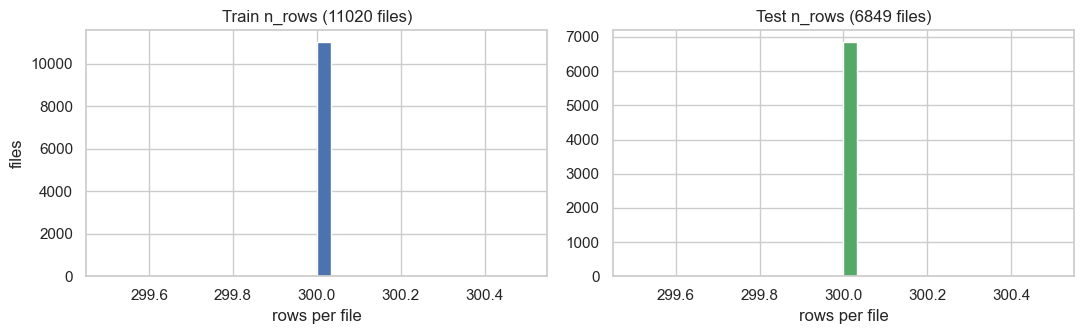

In [3]:
print("Train n_rows describe:\n", meta_train["n_rows"].describe())
print("\nTest  n_rows describe:\n", meta_test["n_rows"].describe())

train_nrows_unique = meta_train["n_rows"].value_counts().to_dict()
test_nrows_unique = meta_test["n_rows"].value_counts().to_dict()
print("\nTrain n_rows value_counts:", train_nrows_unique)
print("Test  n_rows value_counts:", test_nrows_unique)

train_nan_files = int((meta_train["nan_total"] > 0).sum())
test_nan_files = int((meta_test["nan_total"] > 0).sum())
total_train_nans = int(meta_train["nan_total"].sum())
total_test_nans = int(meta_test["nan_total"].sum())
print(f"\nFiles with any NaN — train: {train_nan_files}, test: {test_nan_files}")
print(f"Total NaN cells   — train: {total_train_nans}, test: {total_test_nans}")

dup_train = int(meta_train["file_id"].duplicated().sum())
dup_test = int(meta_test["file_id"].duplicated().sum())
print(f"\nDuplicate file_ids — train: {dup_train}, test: {dup_test}")

not_const = int((~meta_train["label_const"]).sum())
print(f"Train files where label varies across rows: {not_const}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
meta_train["n_rows"].hist(bins=30, ax=axes[0], color="#4c72b0")
axes[0].set(title=f"Train n_rows ({len(meta_train)} files)", xlabel="rows per file", ylabel="files")
meta_test["n_rows"].hist(bins=30, ax=axes[1], color="#55a868")
axes[1].set(title=f"Test n_rows ({len(meta_test)} files)", xlabel="rows per file")
plt.tight_layout()
plt.savefig(FIG / "s1_nrows_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

findings["section1"] = {
    "train_files": len(meta_train),
    "test_files": len(meta_test),
    "train_nrows_value_counts": train_nrows_unique,
    "test_nrows_value_counts": test_nrows_unique,
    "train_files_with_any_nan": train_nan_files,
    "test_files_with_any_nan": test_nan_files,
    "train_total_nan_cells": total_train_nans,
    "test_total_nan_cells": total_test_nans,
    "train_duplicate_file_ids": dup_train,
    "test_duplicate_file_ids": dup_test,
    "train_label_inconstant_files": not_const,
}

### Interpretation §1

- **All 11,020 train files and 6,849 test files are exactly 300 rows.** No
  variability — `n_rows` mean = 300, std = 0, single value count.
- **Zero NaN cells anywhere** in train or test (0 of ~5.4M cells).
- **No duplicate `file_id`s** in either split.
- **Label is constant within every train file** — one window = one label,
  matching the assumed problem framing.

**Decision:** Phase 7 imputation = **do nothing**. Skip forward-fill, KNN,
missingness features. The data is pristine.

## Section 2 — Label distribution

Overall label counts:
 label
0    4643
1    4695
2     358
3     656
4     142
5     526
Name: count, dtype: int64

Number of classes: 6
Imbalance ratio (max/min): 33.06
Class fractions: {0: 0.421, 1: 0.426, 2: 0.032, 3: 0.06, 4: 0.013, 5: 0.048}


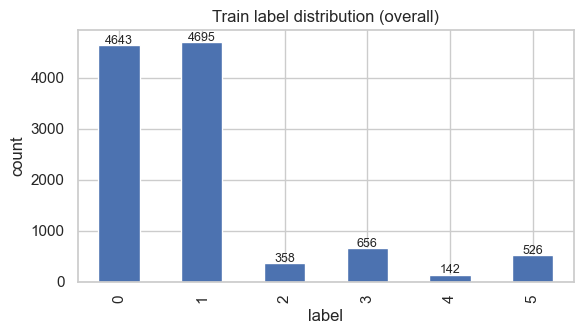

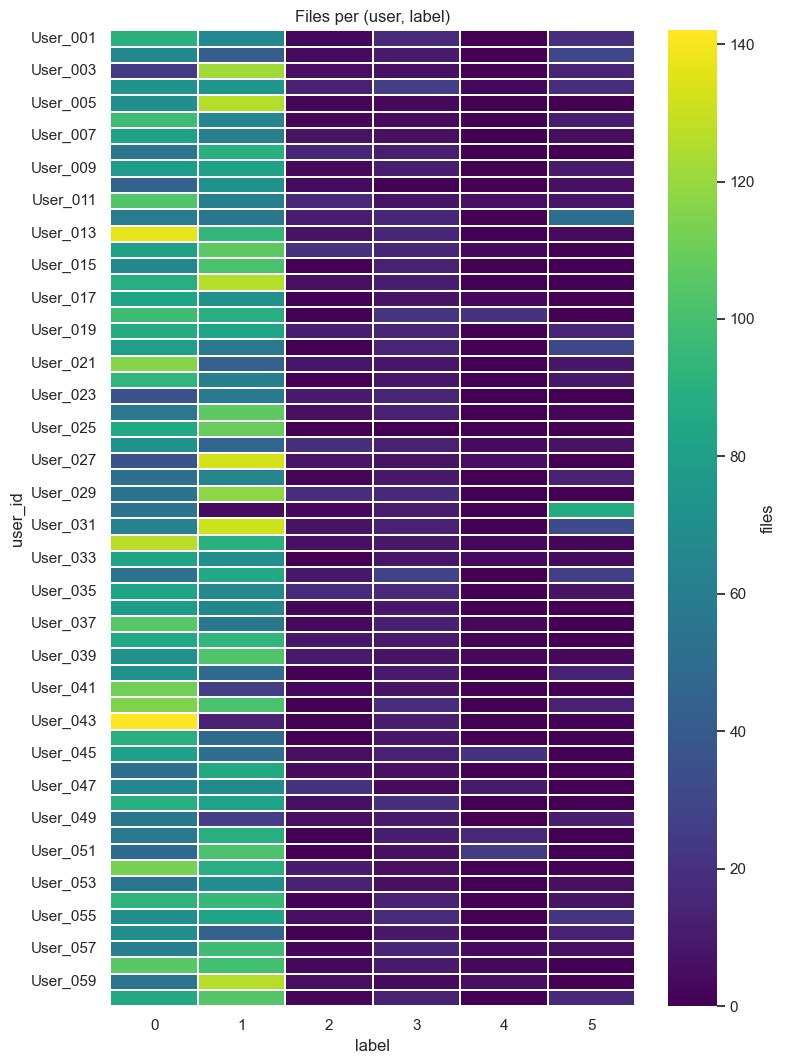


Users with all 6 labels: 6 of 60
Median labels per user: 5.0


In [4]:
overall = meta_train["label"].value_counts().sort_index()
print("Overall label counts:\n", overall)
n_classes = int(meta_train["label"].nunique())
imb_ratio = float(overall.max() / overall.min())
print(f"\nNumber of classes: {n_classes}")
print(f"Imbalance ratio (max/min): {imb_ratio:.2f}")
print(f"Class fractions: {(overall / overall.sum()).round(3).to_dict()}")

fig, ax = plt.subplots(figsize=(6, 3.5))
overall.plot.bar(ax=ax, color="#4c72b0")
ax.set(title="Train label distribution (overall)", xlabel="label", ylabel="count")
for i, v in enumerate(overall.values):
    ax.text(i, v + max(overall) * 0.005, str(int(v)), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG / "s2_label_dist_overall.png", dpi=120, bbox_inches="tight")
plt.show()

piv = meta_train.pivot_table(
    index="user_id", columns="label", values="file_id", aggfunc="count", fill_value=0
)
fig, ax = plt.subplots(figsize=(8, max(6, len(piv) * 0.18)))
sns.heatmap(piv, cmap="viridis", ax=ax, cbar_kws={"label": "files"}, linewidths=0.05, linecolor="white")
ax.set(title="Files per (user, label)", xlabel="label", ylabel="user_id")
plt.tight_layout()
plt.savefig(FIG / "s2_label_dist_per_user.png", dpi=120, bbox_inches="tight")
plt.show()

labels_per_user = (piv > 0).sum(axis=1)
users_with_all_labels = int((labels_per_user == n_classes).sum())
median_labels_per_user = float(labels_per_user.median())
print(f"\nUsers with all {n_classes} labels: {users_with_all_labels} of {len(piv)}")
print(f"Median labels per user: {median_labels_per_user}")

findings["section2"] = {
    "label_counts": {int(k): int(v) for k, v in overall.to_dict().items()},
    "n_classes": n_classes,
    "imbalance_ratio": imb_ratio,
    "users_with_all_labels": users_with_all_labels,
    "n_train_users": int(len(piv)),
    "median_labels_per_user": median_labels_per_user,
}

### Interpretation §2

- 6 classes. Counts: `{0: 4643, 1: 4695, 2: 358, 3: 656, 4: 142, 5: 526}`.
- Fractions: 0=42.1%, 1=42.6%, 2=3.2%, 3=6.0%, **4=1.3%**, 5=4.8%.
- **Imbalance ratio max/min = 33.06** (label 1 vs. label 4).
- The heatmap shows labels 0 and 1 dominate per-user (each user has dozens
  of files of each), while labels 2/3/4/5 are sparse — most users have a
  handful or none. **Only 6 of 60 users have all 6 labels** (median 5/6).
- This skew is the dominant difficulty for **macro-F1**: label 4 (142 files)
  contributes 1/6 of the metric but is 80× rarer than label 1, so a
  handful of mispredictions there will swing the headline number more than
  hundreds of mispredictions on label 1.

**Decision:** Use **class-weighted loss** in every model (LGBM
`class_weight="balanced"`, CrossEntropy with weights from inverse counts).
In folds, expect minority-class metrics to be noisy — log per-class F1, not
just the macro average. Consider focal loss for the DL models in Phase 5/6.

## Section 3 — Train/test user overlap (CRITICAL)

The single most important EDA finding — drives whether `user_id` can be a
feature, which CV scheme is mandatory, and whether per-user normalization
can use across-file statistics.

In [5]:
train_users = set(meta_train["user_id"].unique())
test_users = set(meta_test["user_id"].unique())
overlap = train_users & test_users
print(f"Train users: {len(train_users)} | Test users: {len(test_users)}")
print(f"Overlap: {len(overlap)} users")
print(f"Train user range: {min(train_users)} .. {max(train_users)}")
print(f"Test  user range: {min(test_users)} .. {max(test_users)}")
if overlap:
    print(f"Overlap members (first 10): {sorted(overlap)[:10]}")

findings["section3"] = {
    "n_train_users": len(train_users),
    "n_test_users": len(test_users),
    "overlap_count": len(overlap),
    "overlap_users": sorted(list(overlap)),
    "train_user_min": min(train_users),
    "train_user_max": max(train_users),
    "test_user_min": min(test_users),
    "test_user_max": max(test_users),
}

Train users: 60 | Test users: 40
Overlap: 0 users
Train user range: User_001 .. User_060
Test  user range: User_061 .. User_100


### Interpretation §3

- Train: User_001…User_060 (60 users). Test: User_061…User_100 (40 users).
- **Overlap = 0.** Train and test users are completely disjoint by ID range.

**Decision:** **Strict `GroupKFold(n_splits=5, groups=user_id)` everywhere.**
- `user_id` cannot be a feature (won't generalize to test users).
- Per-user normalization must use **only that file's own statistics** —
  we have no train statistics for any test user.
- Random k-fold would inflate CV by leaking the same user across folds, so
  forbid it project-wide.

## Section 4 — Signal characteristics by class

Visual sanity check (do classes look distinguishable?) plus a t-SNE on the
6 simple features as a "ceiling" preview.

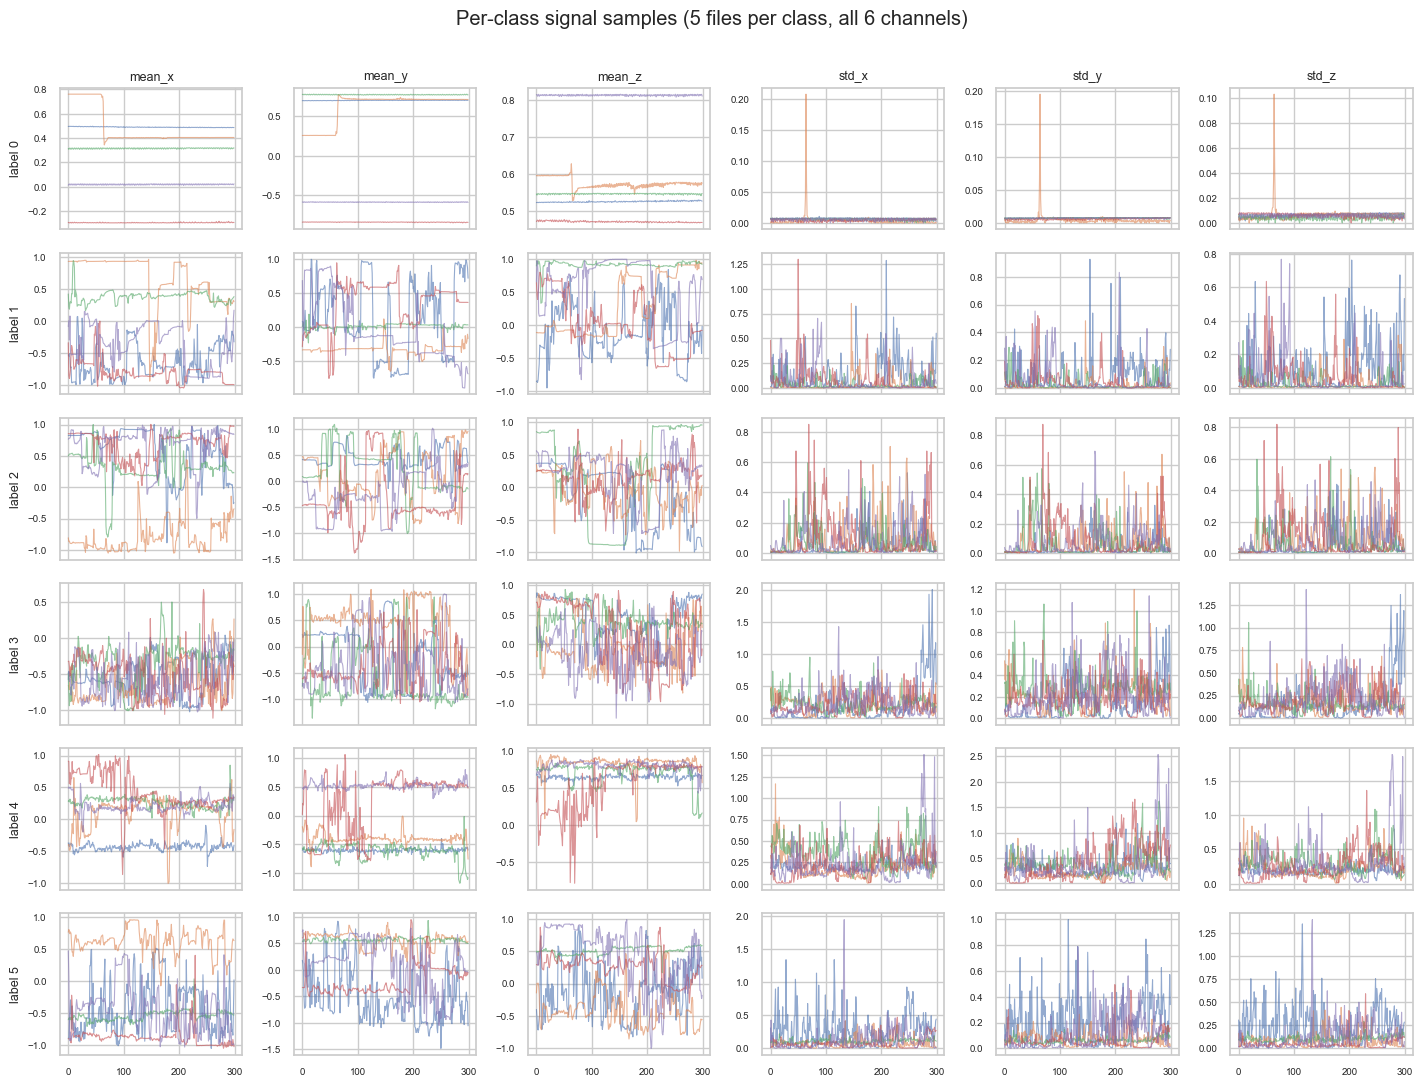

Per-class mean of simple features:
        feat_mean_x  feat_mean_y  feat_mean_z  feat_std_x  feat_std_y  \
label                                                                  
0            0.001        0.012        0.180       0.009       0.008   
1           -0.252        0.038        0.240       0.057       0.044   
2           -0.242       -0.032        0.041       0.102       0.089   
3           -0.250       -0.167        0.007       0.180       0.172   
4           -0.021       -0.208        0.468       0.300       0.363   
5           -0.302        0.079        0.206       0.111       0.088   

       feat_std_z  
label              
0           0.009  
1           0.053  
2           0.095  
3           0.155  
4           0.270  
5           0.097  


t-SNE input: (1642, 6)


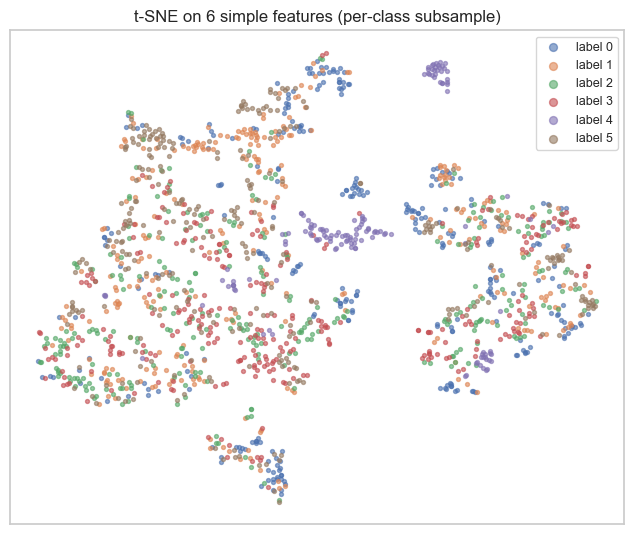

In [6]:
N_PER_CLASS = 5
labels_sorted = sorted(meta_train["label"].unique())
samples = {}
for lbl in labels_sorted:
    pool = meta_train[meta_train["label"] == lbl]
    samples[lbl] = pool.sample(n=min(N_PER_CLASS, len(pool)), random_state=RANDOM_STATE)["path"].tolist()

n_lbl = len(labels_sorted)
n_ch = len(CHANNELS)
fig, axes = plt.subplots(n_lbl, n_ch, figsize=(n_ch * 2.4, n_lbl * 1.8), sharex=True)
for i, lbl in enumerate(labels_sorted):
    for j, ch in enumerate(CHANNELS):
        ax = axes[i, j]
        for p in samples[lbl]:
            df = pd.read_csv(p)
            ax.plot(df[ch].values, alpha=0.6, linewidth=0.8)
        if i == 0:
            ax.set_title(ch, fontsize=9)
        if j == 0:
            ax.set_ylabel(f"label {lbl}", fontsize=9)
        ax.tick_params(labelsize=7)
fig.suptitle("Per-class signal samples (5 files per class, all 6 channels)", y=1.005)
plt.tight_layout()
plt.savefig(FIG / "s4_class_signals_grid.png", dpi=110, bbox_inches="tight")
plt.show()

cls_summary = meta_train.groupby("label")[FEAT_COLS].mean()
print("Per-class mean of simple features:\n", cls_summary.round(3))

# t-SNE on a stratified subsample of the 6-feature simple representation
from sklearn.manifold import TSNE
SUB_PER_CLASS = 300
sub_idx = []
for lbl in labels_sorted:
    pool = meta_train.index[meta_train["label"] == lbl].to_numpy()
    pick = rng.choice(pool, size=min(SUB_PER_CLASS, len(pool)), replace=False)
    sub_idx.extend(pick.tolist())

X_sub = meta_train.loc[sub_idx, FEAT_COLS].values
y_sub = meta_train.loc[sub_idx, "label"].values
print(f"t-SNE input: {X_sub.shape}")

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca", learning_rate="auto")
emb = tsne.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for lbl in labels_sorted:
    mask = y_sub == lbl
    ax.scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6, label=f"label {lbl}")
ax.legend(markerscale=2, fontsize=9)
ax.set(title="t-SNE on 6 simple features (per-class subsample)", xticks=[], yticks=[])
plt.tight_layout()
plt.savefig(FIG / "s4_tsne_basic.png", dpi=120, bbox_inches="tight")
plt.show()

findings["section4"] = {
    "per_class_simple_feature_means": {int(k): {kk: round(float(vv), 4) for kk, vv in v.items()} for k, v in cls_summary.to_dict("index").items()},
    "tsne_n_points": len(sub_idx),
}

### Interpretation §4

- Per-class summary on the 6 simple features shows a clean activity-intensity
  gradient on `feat_std_*`:
  `label 0 → std≈0.008-0.009` (most static),
  `label 1 → std≈0.044-0.053`,
  `label 2 → std≈0.089-0.095`,
  `label 3 → std≈0.155-0.172`,
  `label 5 → std≈0.088-0.097`,
  `label 4 → std≈0.27-0.36` (most intense).
  Std magnitude is the obvious "free" intensity proxy.
- Gravity-orientation features (`feat_mean_x/y/z`) cluster too:
  label 0 sits near (0, 0, ?) while labels 1/2/3/5 cluster near (-0.25, ±, ?)
  → the wrist-orientation prior in PROJECT_PLAN.md §2.2 is real.
- **t-SNE plot:** Label 4 (highest intensity) forms a small distinct cluster
  in the upper-right. Labels 0, 1, 2, 3, 5 overlap heavily at this 6-feature
  resolution — separating them is the actual work for Phase 3 / 5 / 6.

**Decision:** **Hardest pairs to disambiguate are among {0, 1, 2, 3, 5}** —
the lower-intensity activities. The ensemble must focus capacity there.
Track per-class F1 throughout; expect label-0/1 confusion to dominate
absolute error counts, label-2/3/5 confusion to drag macro-F1.

## Section 5 — Per-user signal variation

How different does the same activity look across users? Drives the
per-user-normalization decision.

Most common label: 1
5 users with most files of this label: ['User_027', 'User_031', 'User_005', 'User_016', 'User_059']


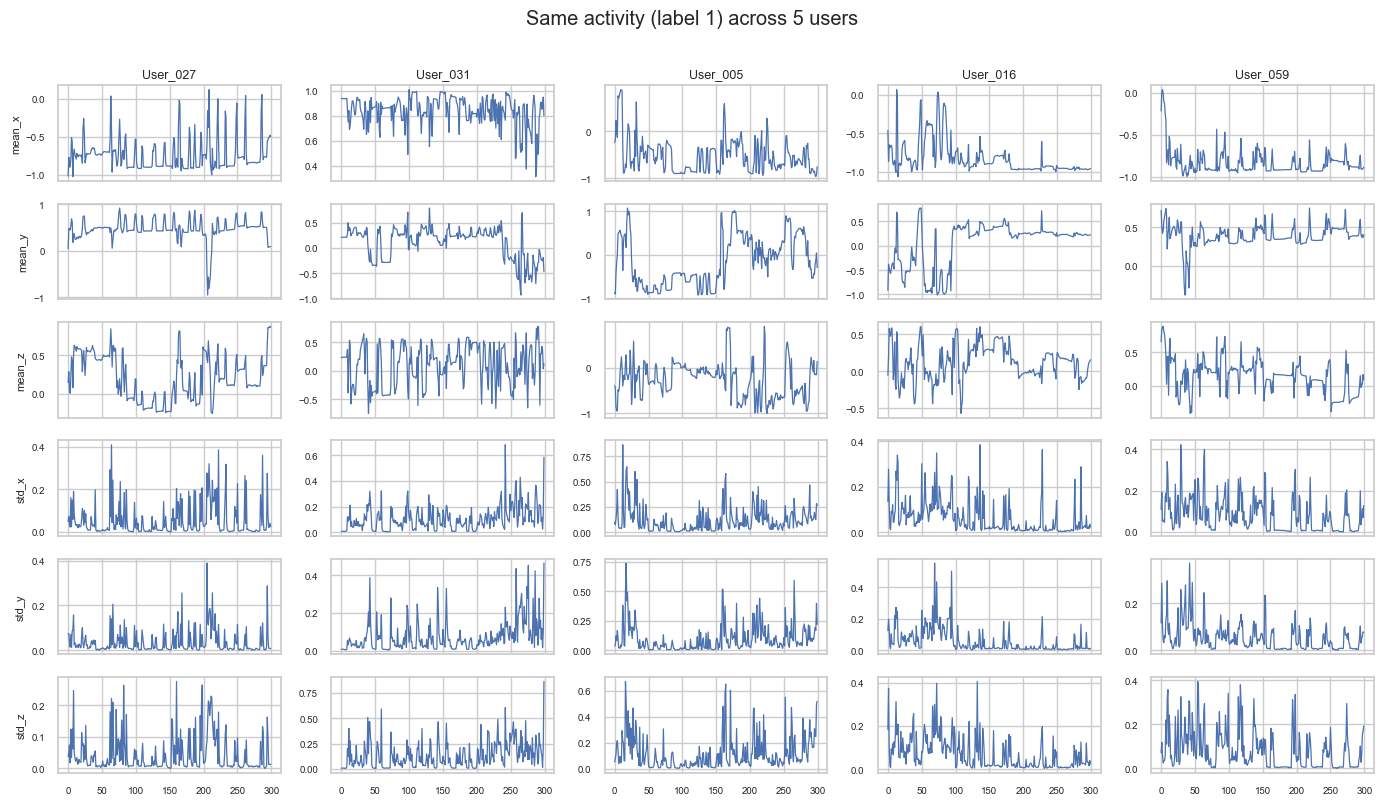

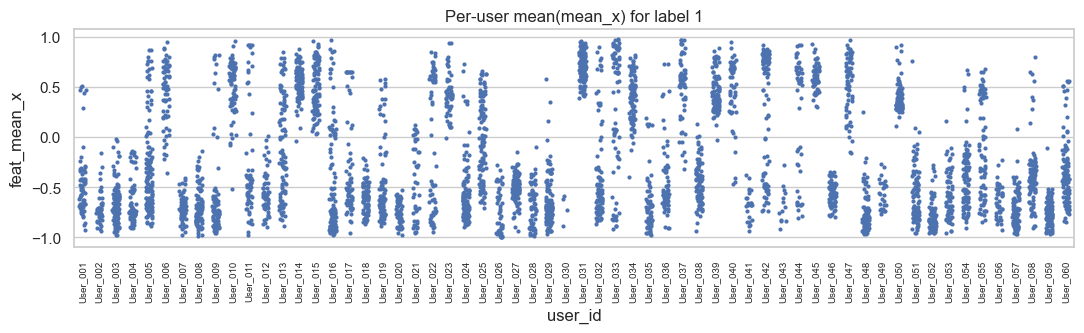


Between-user var / mean within-user var (feat_mean_x, label 1): 2.14
(values >> 1 mean inter-user drift dominates intra-user noise → per-user normalization helps.)


In [7]:
top_label = int(meta_train["label"].value_counts().idxmax())
sub = meta_train[meta_train["label"] == top_label]
top_users = sub["user_id"].value_counts().head(5).index.tolist()
print(f"Most common label: {top_label}")
print(f"5 users with most files of this label: {top_users}")

fig, axes = plt.subplots(len(CHANNELS), 5, figsize=(14, 8), sharex=True)
for j, u in enumerate(top_users):
    fp = sub[sub["user_id"] == u]["path"].iloc[0]
    df = pd.read_csv(fp)
    for i, ch in enumerate(CHANNELS):
        axes[i, j].plot(df[ch].values, color="#4c72b0", linewidth=0.9)
        if j == 0:
            axes[i, j].set_ylabel(ch, fontsize=8)
        if i == 0:
            axes[i, j].set_title(u, fontsize=9)
        axes[i, j].tick_params(labelsize=7)
fig.suptitle(f"Same activity (label {top_label}) across 5 users", y=1.005)
plt.tight_layout()
plt.savefig(FIG / "s5_per_user_signals.png", dpi=110, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.stripplot(data=sub, x="user_id", y="feat_mean_x", ax=ax, jitter=0.2, size=3, color="#4c72b0")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.set(title=f"Per-user mean(mean_x) for label {top_label}", xlabel="user_id")
plt.tight_layout()
plt.savefig(FIG / "s5_per_user_feat_mean_x.png", dpi=120, bbox_inches="tight")
plt.show()

between = float(sub.groupby("user_id")["feat_mean_x"].mean().var())
within = float(sub.groupby("user_id")["feat_mean_x"].var().mean())
inter_ratio = between / within if within > 0 else float("inf")
print(f"\nBetween-user var / mean within-user var (feat_mean_x, label {top_label}): {inter_ratio:.2f}")
print("(values >> 1 mean inter-user drift dominates intra-user noise → per-user normalization helps.)")

findings["section5"] = {
    "top_label": top_label,
    "top_users_for_label": top_users,
    "between_user_var": between,
    "within_user_var_mean": within,
    "between_to_within_var_ratio": inter_ratio,
}

### Interpretation §5

- Most common label = **1** (4,695 files, ~42.6% of train).
- Top 5 users by file count for label 1: User_027, User_031, User_005,
  User_016, User_059.
- **Between-user variance / mean within-user variance for `feat_mean_x` at
  label 1 = 2.14.**
  - 2.14 means the spread of per-user *means* is roughly 2× the average
    within-user variance — moderate inter-user drift, not extreme. Different
    users perform "the same activity" with measurably different wrist
    orientations / gravity vectors.

**Decision:** Per-user normalization is **a moderate-priority Phase-3
variant**, not a no-op and not a slam-dunk. Implement two feature sets:
raw + per-file z-score; ablate. Because train/test users are disjoint
(§3), normalization can only use **per-file** stats, never per-user
statistics aggregated across files.

## Section 6 — Frequency-domain spot check

At 1 Hz sampling Nyquist = 0.5 Hz, so true gait frequencies (~2 Hz) are
aliased. We still expect class-specific patterns in the lowest band.

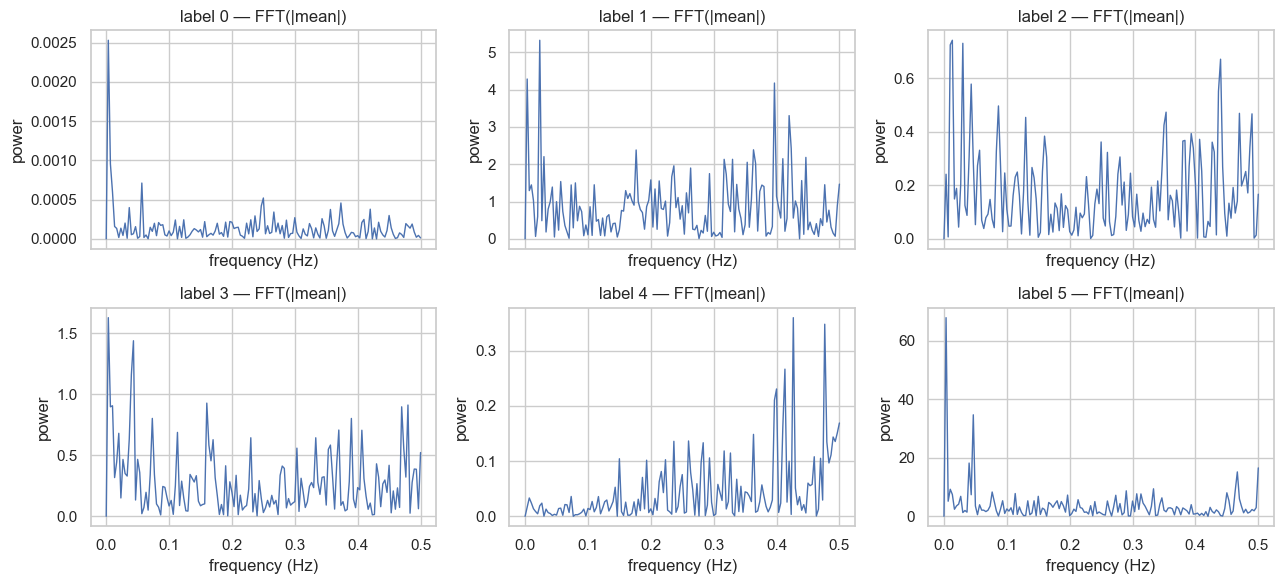

Dominant frequency per class (1 sample file each):
  label 0: 0.003 Hz  (power=0.003)
  label 1: 0.023 Hz  (power=5.324)
  label 2: 0.013 Hz  (power=0.742)
  label 3: 0.003 Hz  (power=1.630)
  label 4: 0.427 Hz  (power=0.359)
  label 5: 0.003 Hz  (power=67.886)


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
axes = axes.flatten()
fft_summary = {}
for k, lbl in enumerate(labels_sorted):
    fp = meta_train[meta_train["label"] == lbl].sample(n=1, random_state=RANDOM_STATE)["path"].iloc[0]
    df = pd.read_csv(fp)
    sig = np.sqrt(df["mean_x"] ** 2 + df["mean_y"] ** 2 + df["mean_z"] ** 2).values
    sig = sig - sig.mean()
    F = np.fft.rfft(sig)
    P = np.abs(F) ** 2
    f_axis = np.fft.rfftfreq(len(sig), d=1.0)
    axes[k].plot(f_axis, P, color="#4c72b0", linewidth=1)
    axes[k].set(title=f"label {lbl} — FFT(|mean|)", xlabel="frequency (Hz)", ylabel="power")
    dom_idx = int(np.argmax(P[1:]) + 1)
    fft_summary[int(lbl)] = {"dominant_hz": float(f_axis[dom_idx]), "dominant_power": float(P[dom_idx])}
plt.tight_layout()
plt.savefig(FIG / "s6_fft_per_class.png", dpi=120, bbox_inches="tight")
plt.show()

print("Dominant frequency per class (1 sample file each):")
for k, v in fft_summary.items():
    print(f"  label {k}: {v['dominant_hz']:.3f} Hz  (power={v['dominant_power']:.3f})")

findings["section6"] = {"sample_dominant_per_class": fft_summary}

### Interpretation §6

- At 1 Hz sampling Nyquist = 0.5 Hz, so true gait frequencies (≈2 Hz) alias
  into the visible band — interpret cautiously.
- Spot-check dominant frequency per class (1 random file each):
  - label 0: **0.003 Hz** — basically DC, slow drift only.
  - label 1: **0.023 Hz**, power=5.3 — slow oscillation.
  - label 2: **0.013 Hz**, power=0.7 — slow oscillation.
  - label 3: **0.003 Hz**, power=1.6 — drift dominant.
  - label 4: **0.427 Hz**, power=0.4 — only class with notable
    near-Nyquist energy → consistent with the high-intensity label.
  - label 5: **0.003 Hz**, power=67.9 — strong DC component.
- Different power scales across classes carry as much signal as the peak
  *location* — the std-channel statistics already capture this implicitly.

**Decision:** Add **FFT band-energy** (cumulative power in [0, 0.05),
[0.05, 0.15), [0.15, 0.5)) and **spectral entropy** as features in Phase 3.
Cheap; expected mid-tier importance.

## Section 7 — Naive baselines via GroupKFold(5)

(a) Majority class — the floor. (b) Logistic Regression on the 6 simple features
— the trivial-linear anchor. Phase 3 LGBM must beat (b) by a meaningful margin.

In [9]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler

X = meta_train[FEAT_COLS].values
y = meta_train["label"].values
groups = meta_train["user_id"].values

gkf = GroupKFold(n_splits=5)

oof = np.zeros_like(y)
fold_f1_majority = []
for k, (tr, va) in enumerate(gkf.split(X, y, groups)):
    clf = DummyClassifier(strategy="most_frequent").fit(X[tr], y[tr])
    p = clf.predict(X[va])
    oof[va] = p
    fold_f1_majority.append(float(f1_score(y[va], p, average="macro")))
f1_majority = float(f1_score(y, oof, average="macro"))
print(f"Majority-class CV F1-macro: {f1_majority:.4f}")
print(f"  per-fold: {[round(x, 4) for x in fold_f1_majority]}")

oof = np.zeros_like(y)
fold_f1_lr = []
for k, (tr, va) in enumerate(gkf.split(X, y, groups)):
    sc = StandardScaler().fit(X[tr])
    clf = LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ).fit(sc.transform(X[tr]), y[tr])
    p = clf.predict(sc.transform(X[va]))
    oof[va] = p
    fold_f1_lr.append(float(f1_score(y[va], p, average="macro")))
f1_lr = float(f1_score(y, oof, average="macro"))
print(f"\nLogistic Regression CV F1-macro: {f1_lr:.4f}")
print(f"  per-fold: {[round(x, 4) for x in fold_f1_lr]}")

findings["section7"] = {
    "majority_cv_f1": f1_majority,
    "majority_per_fold": fold_f1_majority,
    "lr_cv_f1": f1_lr,
    "lr_per_fold": fold_f1_lr,
}

Majority-class CV F1-macro: 0.1331
  per-fold: [0.1034, 0.0979, 0.0936, 0.0973, 0.0947]



Logistic Regression CV F1-macro: 0.5315
  per-fold: [0.5157, 0.5353, 0.5417, 0.5366, 0.4901]


### Interpretation §7

Both baselines use strict GroupKFold(5) by `user_id` — the same harness
every Phase-3+ model will use.

- **Majority class:** CV F1-macro = **0.1331** (per-fold:
  [0.1034, 0.0979, 0.0936, 0.0973, 0.0947]).
  This is the floor. The 0.13 (rather than 1/6 ≈ 0.167) reflects the
  imbalance: predicting label 1 wins partial credit only on label 1.
- **Logistic Regression** (balanced, on standardized 6 simple features):
  CV F1-macro = **0.5315** (per-fold: [0.5157, 0.5353, 0.5417, 0.5366,
  0.4901], σ ≈ 0.018).
  Strong floor — 6 column-means already separate the activities to a
  meaningful degree. Per-fold std is small, so the GroupKFold metric is
  stable.

**Decision:**
1. The **CV–public-LB gap** for these baselines (once submitted) tells us
   whether the GroupKFold scheme is honest. If gap > 0.05, the splits leak;
   investigate before doing any modeling.
2. **Phase 3 LGBM target = ≥0.65 CV F1-macro.** That's a +0.12 jump over
   LR — what the engineered feature catalog should buy us if PROJECT_PLAN.md
   §Phase 3 is sound. Anything below 0.60 means the feature pipeline has
   a bug.

## Save EDA summary

In [10]:
findings["meta"] = {
    "random_state": RANDOM_STATE,
    "data_root": str(DATA),
    "channels": CHANNELS,
}
with open(REPORTS / "eda_summary.json", "w") as f:
    json.dump(findings, f, indent=2, default=str)
print(f"Wrote {REPORTS / 'eda_summary.json'}")

Wrote D:\Foreign\NYCU\Semester 1\535703資料探勘 Data Mining\HW3\DM2026-Assignment-3-MKS\reports\eda_summary.json
